
# CS 512 Group 10 Project: Dominating Set to Min-Sum Multicenter Transformation

## Problem Statement
We aim to reduce the **Dominating Set problem** (NP-complete) to the **Min-Sum Multicenter problem** (MSMC) in polynomial time, thereby proving that MSMC is NP-hard.

- **Dominating Set**: Given a graph \( G = (V, E) \) and integer \( k \), does there exist a set $$ D \subseteq V $$, with $$ |D| \leq k $$, such that every vertex is either in \( D \) or adjacent to a vertex in \( D \)?
- **Min-Sum Multicenter (MSMC)**: Given a graph \( G' = (V', E') \), integer \( k' \), and a budget \( B \), does there exist a set $$ S \subseteq V' $$, with $$ |S| = k' $$, such that $$ \sum_{v \in V'} \min_{s \in S} 	ext{dist}(v, s) \leq B $$?

## Transformation Logic
- Construct \( G' \) as a complete graph over the same node set as \( G \)
- Assign edge weights as follows:
  - 1 if edge exists in \( G \)
  - 999 if no edge exists (to simulate domination constraint)
- Set \( k' = k \)
- Set \( B = n - k \), where \( n = |V| \)

This transformation ensures a "YES" instance in Dominating Set corresponds to a "YES" instance in Min-Sum Multicenter, and vice versa.


In [1]:

import networkx as nx
import matplotlib.pyplot as plt
import itertools


In [2]:

def load_graph_from_csv(filename):
    G = nx.Graph()
    with open(filename, 'r') as f:
        for line in f:
            nodes = line.strip().split(',')
            if len(nodes) == 2:
                G.add_edge(int(nodes[0]), int(nodes[1]))
            elif len(nodes) == 1:
                G.add_node(int(nodes[0]))
    return G


In [3]:

def transform_dominating_to_minsum(G, k):
    G_prime = nx.Graph()
    nodes = list(G.nodes())
    for i, u in enumerate(nodes):
        for v in nodes[i+1:]:
            if G.has_edge(u, v):
                G_prime.add_edge(u, v, weight=1)
            else:
                G_prime.add_edge(u, v, weight=999)
    B = len(G.nodes()) - k
    return G_prime, k, B


In [4]:

def compute_min_sum(G, centers):
    total = 0
    for v in G.nodes():
        if v in centers:
            continue
        dists = [G[v][s]['weight'] for s in centers if G.has_edge(v, s)]
        total += min(dists) if dists else 999
    return total

def find_best_centers(G, k, B):
    best = None
    best_cost = float('inf')
    for centers in itertools.combinations(G.nodes(), k):
        cost = compute_min_sum(G, centers)
        if cost <= B and cost < best_cost:
            best = centers
            best_cost = cost
    return best, best_cost

def is_dominating_set(G, dom_set):
    for v in G.nodes():
        if v not in dom_set and not any(u in dom_set for u in G.neighbors(v)):
            return False
    return True


In [5]:

def visualize_graph(G, title, highlight_nodes=None):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
    if highlight_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=highlight_nodes, node_color='red', node_size=600)
    edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('weight', 1) == 1]
    nx.draw_networkx_edges(G, pos, edgelist=edges)
    nx.draw_networkx_labels(G, pos)
    plt.title(title)
    plt.axis('off')
    plt.show()



Budget B = 9

Transformed Graph Edges (weight=1 only):
3 -- 4, weight=1
3 -- 12, weight=1
3 -- 5, weight=1
4 -- 12, weight=1
4 -- 5, weight=1
12 -- 15, weight=1
5 -- 15, weight=1
15 -- 8, weight=1
9 -- 11, weight=1
9 -- 1, weight=1
9 -- 13, weight=1
11 -- 10, weight=1
11 -- 7, weight=1
1 -- 10, weight=1
1 -- 2, weight=1
13 -- 6, weight=1
13 -- 0, weight=1
10 -- 2, weight=1
7 -- 14, weight=1
7 -- 0, weight=1
8 -- 6, weight=1
8 -- 14, weight=1
6 -- 2, weight=1
14 -- 0, weight=1


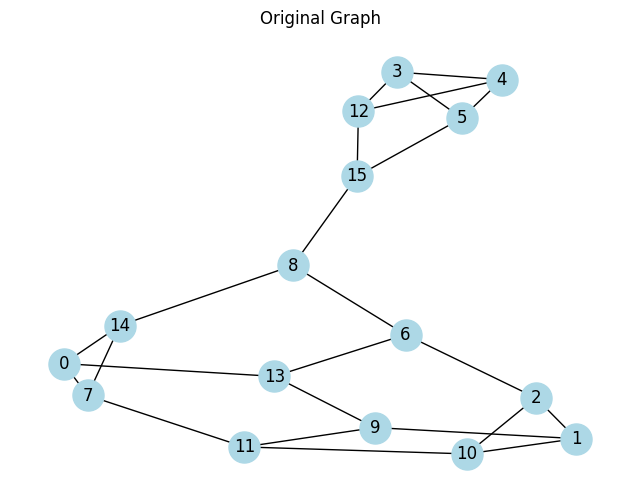

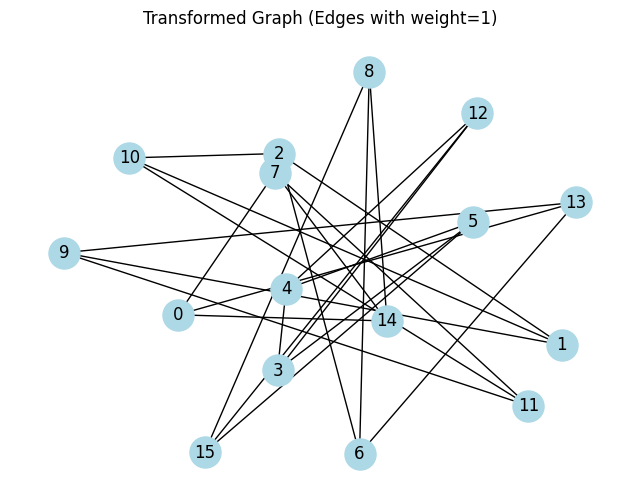


=== Brute-Force Result ===
✔️ Centers: (3, 4, 12, 5, 9, 14, 2)
Total Cost: 9
Instance Type: YES (A set of centers satisfying the budget was found)
Verification: ✅ The centers form a dominating set in the original graph


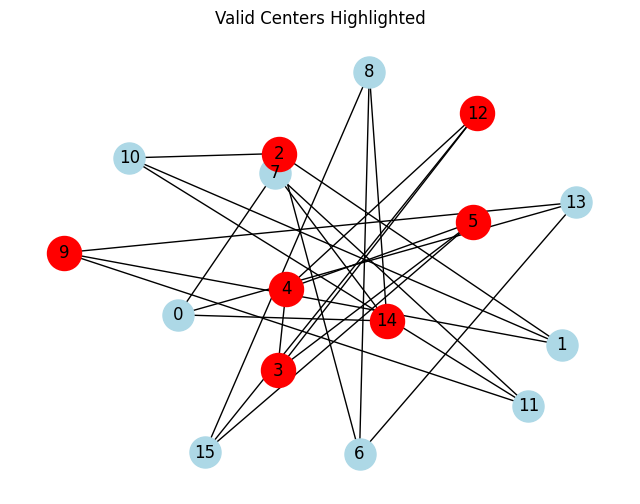

In [10]:

if __name__ == '__main__':
    G = load_graph_from_csv("input_16 vertices.csv")
    n = G.number_of_nodes()
    k = 7

    G_prime, k_prime, B = transform_dominating_to_minsum(G, k)
    print(f"\nBudget B = {B}\n")

    print("Transformed Graph Edges (weight=1 only):")
    for u, v, d in G_prime.edges(data=True):
        if d['weight'] == 1:
            print(f"{u} -- {v}, weight=1")

    visualize_graph(G, "Original Graph")
    visualize_graph(G_prime, "Transformed Graph (Edges with weight=1)")

    centers, cost = find_best_centers(G_prime, k, B)
    print("\n=== Brute-Force Result ===")
    if centers:
        print(f"✔️ Centers: {centers}")
        print(f"Total Cost: {cost}")
        print(f"Instance Type: YES (A set of centers satisfying the budget was found)")
        if is_dominating_set(G, centers):
            print("Verification: ✅ The centers form a dominating set in the original graph")
        else:
            print("Verification: ❌ The centers do NOT form a dominating set in the original graph")
        visualize_graph(G_prime, "Valid Centers Highlighted", highlight_nodes=centers)
    else:
        print("❌ No valid center set found within budget")
        print("Instance Type: NO (No set of centers satisfies the budget)")
